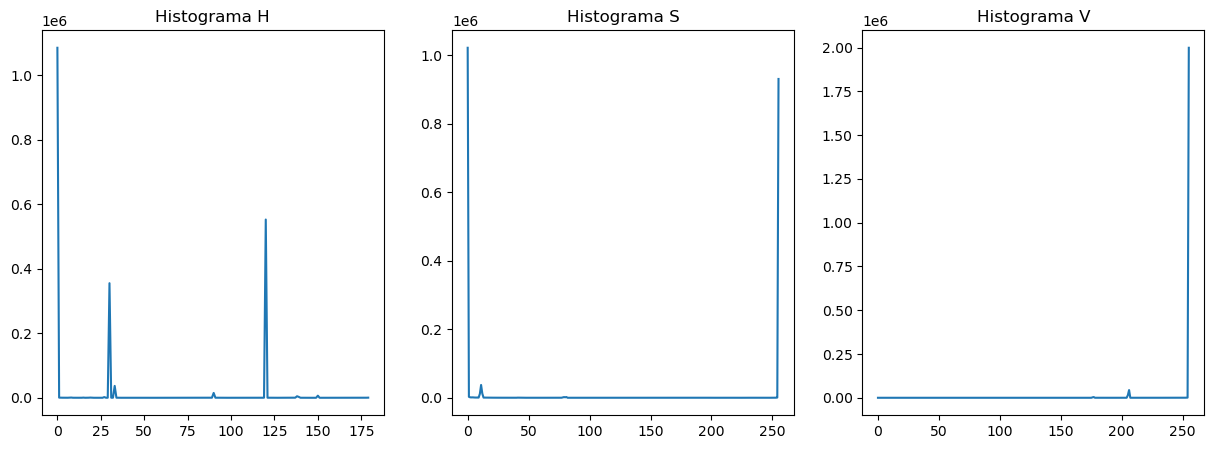

In [2]:
from dotenv import load_dotenv
from core.validation import get_valid_image_number
import cv2 as cv
import matplotlib.pyplot as plt
import os


load_dotenv()
base_mask_folder: str = os.getenv("BASE_MASK_FOLDER")
output_folder: str = os.getenv("OUTPUT_FOLDER")
img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

# Carregar a imagem
img = cv.imread(mask_path, 1)

# Converter para HSV
hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)

# Calcular o histograma para cada canal (H, S, V)
hist_h = cv.calcHist([hsv], [0], None, [180], [0, 180])  # Canal H (0-179)
hist_s = cv.calcHist([hsv], [1], None, [256], [0, 256])  # Canal S (0-255)
hist_v = cv.calcHist([hsv], [2], None, [256], [0, 256])  # Canal V (0-255)

# Plotar os histogramas
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(hist_h)
plt.title('Histograma H')
plt.subplot(1, 3, 2)
plt.plot(hist_s)
plt.title('Histograma S')
plt.subplot(1, 3, 3)
plt.plot(hist_v)
plt.title('Histograma V')
plt.show()